# DATA 6400 — Qwen3.5-9B Zero-Shot Prompt Rewording

This notebook:
1. installs clean dependencies for Colab
2. mounts Google Drive and uses it as the Hugging Face cache
3. loads the DiFraud `product_reviews` dataset
4. recreates the exact token-quantile length groups from the main notebook
5. loads **Qwen3.5-9B** in 4-bit
6. tests **5 zero-shot prompt rewordings**
7. evaluates **accuracy, precision, recall, and F1**
8. reports results overall and by length group
9. computes prompt disagreement
10. saves outputs to `/content/` and Google Drive

After running the install cell, restart the runtime and continue from the next cell.

In [7]:
!pip -q uninstall -y numpy pandas datasets transformers
!pip -q install --no-cache-dir numpy==1.26.4 pandas==2.2.2 datasets==2.18.0
!pip -q install --no-cache-dir "transformers @ git+https://github.com/huggingface/transformers.git@main"
!pip -q install --no-cache-dir accelerate bitsandbytes sentencepiece scikit-learn matplotlib tqdm
print("Installed clean versions. Restart the runtime now, then continue.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 353.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 357.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 363.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires transformers, which is not installed.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you

## After the install cell
Go to **Runtime → Restart session**.

Then continue from the next cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["HF_HOME"] = "/content/drive/MyDrive/huggingface_cache"

print("Cache path set:", os.environ["HF_HOME"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache path set: /content/drive/MyDrive/huggingface_cache


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/huggingface_cache"))

True


In [1]:
import numpy as np
import pandas as pd
import datasets
import transformers

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)

numpy: 1.26.4
pandas: 2.2.2
datasets: 2.18.0
transformers: 5.6.0.dev0


In [3]:
import os
import gc
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import datasets

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


In [4]:
ds = load_dataset("difraud/difraud", "product_reviews", trust_remote_code=True)
print(ds)
print("\nColumns:", ds["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16776
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2097
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2098
    })
})

Columns: ['text', 'label']


In [5]:
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

print("=== Train null check ===")
print(train_df.isnull().sum())

print("\n=== Class balance (train) ===")
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True))

print("\n=== Test set shape ===")
print(test_df.shape)
print(test_df["label"].value_counts())

=== Train null check ===
text     0
label    0
dtype: int64

=== Class balance (train) ===
label
1    8393
0    8383
Name: count, dtype: int64
label
1    0.500298
0    0.499702
Name: proportion, dtype: float64

=== Test set shape ===
(2098, 2)
label
1    1050
0    1048
Name: count, dtype: int64


In [6]:
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def count_tokens(example):
    tokens = roberta_tokenizer.tokenize(example["text"])
    example["n_tokens"] = len(tokens) + 2
    return example

ds = ds.map(count_tokens)

train_lengths = ds["train"]["n_tokens"]
Q1 = np.quantile(train_lengths, 0.33)
Q2 = np.quantile(train_lengths, 0.66)

print(f"Quantile thresholds — Q1 (33rd): {Q1} | Q2 (66th): {Q2}")

def assign_length_group(example):
    if example["n_tokens"] <= Q1:
        example["length_group"] = "short"
    elif example["n_tokens"] <= Q2:
        example["length_group"] = "medium"
    else:
        example["length_group"] = "long"
    return example

ds = ds.map(assign_length_group)

print("Train:", Counter(ds["train"]["length_group"]))
print("Val  :", Counter(ds["validation"]["length_group"]))
print("Test :", Counter(ds["test"]["length_group"]))

test_qwen = pd.DataFrame(ds["test"])
print("Test DataFrame shape:", test_qwen.shape)
test_qwen.head(3)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

Train: Counter({'long': 5666, 'short': 5622, 'medium': 5488})
Val  : Counter({'long': 731, 'medium': 696, 'short': 670})
Test : Counter({'long': 722, 'short': 699, 'medium': 677})
Test DataFrame shape: (2098, 4)


,text,label,n_tokens,length_group
0,I bought this at a local mart store for under ...,0,148,long
1,So bad experience. Got defected unit and they ...,1,73,long
2,Update 11/28/2015 - Almost 2 years later and t...,0,140,long


In [7]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

QWEN_MODEL = "Qwen/Qwen3.5-9B"

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer: {QWEN_MODEL}")
qwen_tok = AutoTokenizer.from_pretrained(QWEN_MODEL)

if qwen_tok.pad_token is None:
    qwen_tok.pad_token = qwen_tok.eos_token

print(f"Loading model (4-bit NF4): {QWEN_MODEL}")
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    quantization_config=quant_cfg,
    device_map="auto",
    low_cpu_mem_usage=True,
)

qwen_model.eval()
print("\n✓ Model loaded successfully.")

Loading tokenizer: Qwen/Qwen3.5-9B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]


✓ Model loaded successfully.


In [8]:
SYSTEM_MSG = (
    "You are an expert classifier for fake product reviews. "
    "You may think internally, but your final response must end with exactly one line in this format: "
    "FINAL_LABEL: FAKE or FINAL_LABEL: REAL. "
    "Do not end with anything else after that final line."
)



PROMPT_D = """You are a fraud detection expert specialised in e-commerce review authenticity.
FAKE reviews are often generated or incentivised. They use generic praise, emotional superlatives, or suspicious promotional language.
REAL reviews reflect authentic consumer experience with specific, verifiable details.

Return your final decision on the last line exactly as:
FINAL_LABEL: FAKE
or
FINAL_LABEL: REAL

Review:
{review}
"""

PROMPT_E = """Read the product review below and decide whether it sounds genuine or fabricated.

Return your final decision on the last line exactly as:
FINAL_LABEL: FAKE
or
FINAL_LABEL: REAL

Review:
{review}
"""

PROMPTS = {

    "prompt_D": PROMPT_D,
    "prompt_E": PROMPT_E,
}

print(f"✓ {len(PROMPTS)} prompts defined.")

✓ 2 prompts defined.


In [9]:
def parse_output(text: str):
    if text is None:
        return None

    t = text.strip().upper()

    # Best case: explicit final label
    m = re.search(r"FINAL_LABEL:\s*(FAKE|REAL)", t)
    if m:
        return 1 if m.group(1) == "FAKE" else 0

    # Fallback: last FAKE/REAL mention anywhere
    hits = re.findall(r"\b(FAKE|REAL)\b", t)
    if hits:
        return 1 if hits[-1] == "FAKE" else 0

    if any(w in t for w in ["DECEPTIVE", "FRAUDULENT", "FABRICATED", "INAUTHENTIC"]):
        return 1
    if any(w in t for w in ["GENUINE", "AUTHENTIC", "LEGITIMATE"]):
        return 0

    return None


def classify_review(review_text: str, prompt_template: str,
                    max_input_length: int = 1024, max_new_tokens: int = 120):
    prompt = prompt_template.format(review=review_text)

    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user", "content": prompt},
    ]

    formatted = qwen_tok.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    try:
        inputs = qwen_tok(
            formatted,
            return_tensors="pt",
            truncation=True,
            max_length=max_input_length
        ).to(qwen_model.device)

        with torch.no_grad():
            out = qwen_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=qwen_tok.eos_token_id,
            )

        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        raw = qwen_tok.decode(new_tokens, skip_special_tokens=True).strip()
        parsed = parse_output(raw)

        return raw, parsed

    except Exception as e:
        print(f"[ERROR] {e}")
        return None, None


In [10]:
sample_text = test_qwen.iloc[0]["text"]
raw_out, parsed = classify_review(sample_text, PROMPT_D)

print("Sanity check (Prompt D)")
print("Review (first 200 chars):", sample_text[:200])
print(f"Model output: {raw_out!r} -> parsed: {parsed}")

assert parsed is not None, "Sanity check FAILED — check model output above."
print("✓ Sanity check passed.")

Sanity check (Prompt D)
Review (first 200 chars): I bought this at a local mart store for under six bucks. It's a nice sized bottle of make up remover and really does take off make up that other removers leave behind. I only use the "stay-put paint-o
Model output: 'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Role: Fraud detection expert specialized in e-commerce review authenticity.\n    *   Task: Classify a product review as FAKE or REAL.\n    *   Criteria:\n        *   FAKE: Generic praise, emotional superlatives, suspicious promotional language.\n        *   REAL: Authentic consumer experience, specific, verifiable details.\n    *   Output Format: Exactly one line at the end: `FINAL_LABEL: FAKE` or `FINAL_LABEL: REAL`.\n\n2.  **' -> parsed: 1
✓ Sanity check passed.


In [11]:
RUN_FULL = False
N_PER_GROUP = 33   # 33 short + 33 medium + 34 long = 100 total

short_df = test_qwen[test_qwen["length_group"] == "short"].sample(n=33, random_state=42)
medium_df = test_qwen[test_qwen["length_group"] == "medium"].sample(n=33, random_state=42)
long_df = test_qwen[test_qwen["length_group"] == "long"].sample(n=34, random_state=42)

eval_df = pd.concat([short_df, medium_df, long_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Evaluating {len(eval_df)} reviews.")
print(eval_df["length_group"].value_counts())


for prompt_name, prompt_template in PROMPTS.items():
    print(f"\n{'='*60}")
    print(f"Prompt: {prompt_name}")
    print(f"{'='*60}")

    raw_col = f"raw_{prompt_name}"
    pred_col = f"pred_{prompt_name}"
    raws, preds, failed = [], [], 0
    ckpt = f"/content/qwen_{prompt_name}_checkpoint.csv"

    for i, review in enumerate(tqdm(eval_df["text"], desc=prompt_name)):
        raw, label = classify_review(review, prompt_template)
        raws.append(raw)
        preds.append(label)

        if label is None:
            failed += 1

        if (i + 1) % 200 == 0 or (i + 1) == len(eval_df):
            tmp = eval_df.iloc[: i + 1].copy()
            tmp[raw_col] = raws
            tmp[pred_col] = preds
            tmp.to_csv(ckpt, index=False)
            print(f"Checkpoint: {i+1}/{len(eval_df)} | failed: {failed}")

    eval_df[raw_col] = raws
    eval_df[pred_col] = preds
    print(f"✓ Done — total failed: {failed}/{len(eval_df)}")

Evaluating 100 reviews.
length_group
long      34
medium    33
short     33
Name: count, dtype: int64

Prompt: prompt_D


prompt_D:   0%|          | 0/100 [00:00<?, ?it/s]

Checkpoint: 100/100 | failed: 0
✓ Done — total failed: 0/100

Prompt: prompt_E


prompt_E:   0%|          | 0/100 [00:00<?, ?it/s]

Checkpoint: 100/100 | failed: 0
✓ Done — total failed: 0/100


In [12]:
print("\n" + "="*60)
print("OVERALL METRICS — Qwen3.5-9B Zero-Shot (5 prompts)")
print("="*60)

overall_rows = []

for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)

    y_true = valid["label"]
    y_pred = valid[pred_col]

    row = {
        "prompt": prompt_name,
        "n_valid": len(valid),
        "n_failed": len(eval_df) - len(valid),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }
    overall_rows.append(row)

    print(f"\n── {prompt_name} ──")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

overall_df = pd.DataFrame(overall_rows)

print("\n=== Summary Table ===")
print(overall_df.to_string(index=False))


OVERALL METRICS — Qwen3.5-9B Zero-Shot (5 prompts)

── prompt_D ──
              precision    recall  f1-score   support

        Real       0.45      0.09      0.16        53
        Fake       0.46      0.87      0.60        47

    accuracy                           0.46       100
   macro avg       0.46      0.48      0.38       100
weighted avg       0.46      0.46      0.37       100


── prompt_E ──
              precision    recall  f1-score   support

        Real       1.00      0.04      0.07        53
        Fake       0.48      1.00      0.65        47

    accuracy                           0.49       100
   macro avg       0.74      0.52      0.36       100
weighted avg       0.76      0.49      0.34       100


=== Summary Table ===
  prompt  n_valid  n_failed  accuracy  precision  recall     f1
prompt_D      100         0      0.46     0.4607  0.8723 0.6029
prompt_E      100         0      0.49     0.4796  1.0000 0.6483


In [13]:
group_rows = []

for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    for group in ["short", "medium", "long"]:
        sub = eval_df[
            (eval_df["length_group"] == group) &
            (eval_df[pred_col].notna())
        ].copy()

        if len(sub) == 0:
            continue

        sub[pred_col] = sub[pred_col].astype(int)

        y_true = sub["label"]
        y_pred = sub[pred_col]

        group_rows.append({
            "prompt": prompt_name,
            "length_group": group,
            "n": len(sub),
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "f1": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        })

group_df = pd.DataFrame(group_rows)

print("=== Metrics by Length Group ===")
print(group_df.to_string(index=False))

=== Metrics by Length Group ===
  prompt length_group  n  accuracy  precision  recall     f1
prompt_D        short 33    0.4242     0.4074  0.7857 0.5366
prompt_D       medium 33    0.5152     0.5333  0.8889 0.6667
prompt_D         long 34    0.4412     0.4375  0.9333 0.5957
prompt_E        short 33    0.4242     0.4242  1.0000 0.5957
prompt_E       medium 33    0.5455     0.5455  1.0000 0.7059
prompt_E         long 34    0.5000     0.4688  1.0000 0.6383


Best prompt by F1: prompt_E


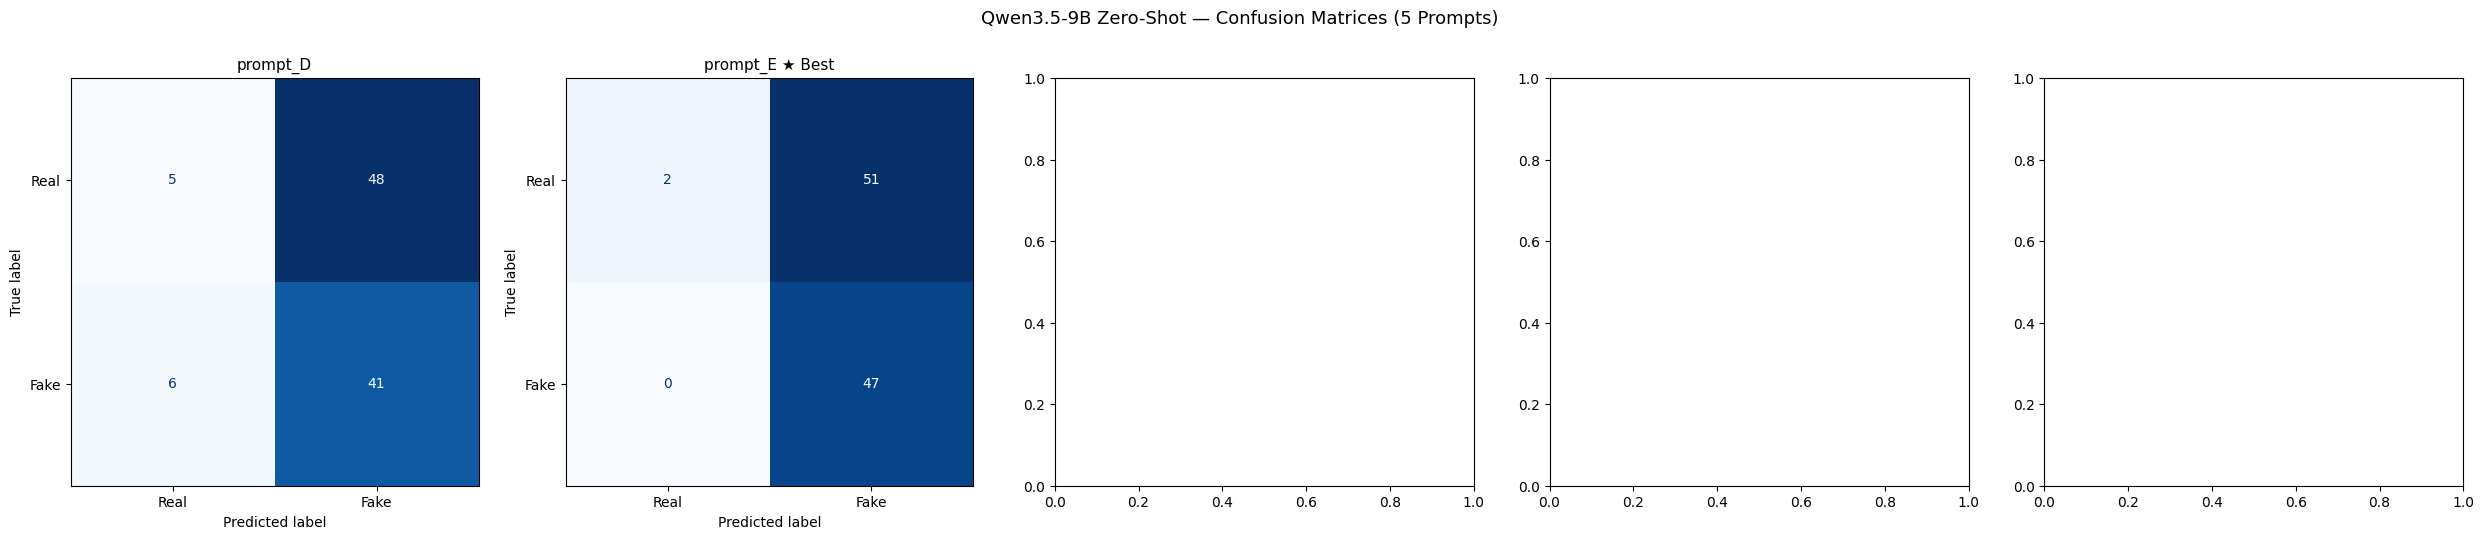

Saved: /content/qwen_confusion_matrices.png


In [14]:
best_prompt = overall_df.loc[overall_df["f1"].idxmax(), "prompt"]
print(f"Best prompt by F1: {best_prompt}")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, prompt_name in zip(axes, PROMPTS):
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)

    cm = confusion_matrix(valid["label"], valid[pred_col])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    title = prompt_name + (" ★ Best" if prompt_name == best_prompt else "")
    ax.set_title(title, fontsize=11)

plt.suptitle("Qwen3.5-9B Zero-Shot — Confusion Matrices (5 Prompts)", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("/content/qwen_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_confusion_matrices.png")

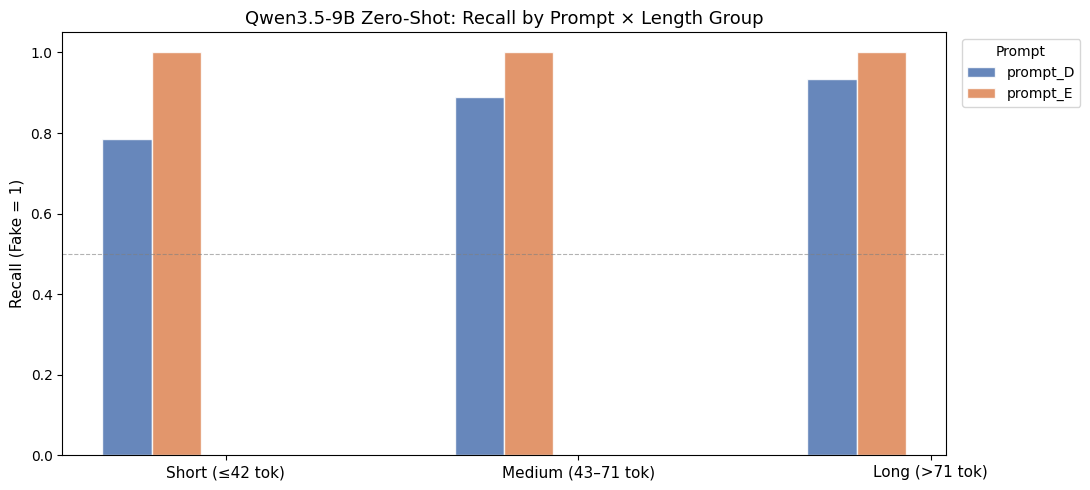

Saved: /content/qwen_recall_by_length.png


In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_w = 0.14
x = np.arange(3)
groups = ["short", "medium", "long"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for idx, prompt_name in enumerate(PROMPTS):
    recalls = []
    for g in groups:
        row = group_df[(group_df["prompt"] == prompt_name) & (group_df["length_group"] == g)]
        recalls.append(row["recall"].values[0] if len(row) > 0 else 0.0)

    offset = (idx - 2) * bar_w
    ax.bar(x + offset, recalls, width=bar_w, label=prompt_name,
           color=colors[idx], alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["Short (≤42 tok)", "Medium (43–71 tok)", "Long (>71 tok)"], fontsize=11)
ax.set_ylabel("Recall (Fake = 1)", fontsize=11)
ax.set_title("Qwen3.5-9B Zero-Shot: Recall by Prompt × Length Group", fontsize=13)
ax.legend(title="Prompt", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("/content/qwen_recall_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_recall_by_length.png")

Overall prompt disagreement rate: 0.110

Disagreement by length group:
length_group
long      0.058824
medium    0.090909
short     0.181818


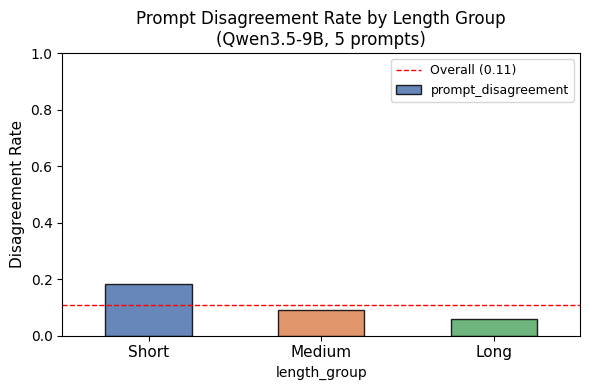

Saved: /content/qwen_disagreement_by_length.png
Sample reviews where prompts disagree:
                                                                                                                                                                                                                                                                  text  label length_group  pred_prompt_D  pred_prompt_E
3   The gauge doesn't work properly! Be very careful using this. Your tires could blow if you put too much air in them. There should be regulations on these or something. I wouldn't recommend this to any of my friends. Find something that's going to be accurate.      1       medium              0              1
10                                                                                                                                 the black is very faded and noticeable. Its very soft and comfy but i wish the black was a little stronger and didnt look as cheap.      0        short     

In [16]:
pred_cols = [f"pred_{p}" for p in PROMPTS]

complete = eval_df.dropna(subset=pred_cols).copy()

for c in pred_cols:
    complete[c] = complete[c].astype(int)

complete["prompt_disagreement"] = complete[pred_cols].nunique(axis=1) > 1

overall_dis = complete["prompt_disagreement"].mean()
print(f"Overall prompt disagreement rate: {overall_dis:.3f}")

dis_by_len = complete.groupby("length_group")["prompt_disagreement"].mean()
print("\nDisagreement by length group:")
print(dis_by_len.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
dis_by_len.reindex(["short", "medium", "long"]).plot(
    kind="bar",
    ax=ax,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="black",
    alpha=0.85
)

ax.set_xticklabels(["Short", "Medium", "Long"], rotation=0, fontsize=11)
ax.set_ylabel("Disagreement Rate", fontsize=11)
ax.set_title("Prompt Disagreement Rate by Length Group\n(Qwen3.5-9B, 5 prompts)", fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(overall_dis, color="red", linestyle="--", linewidth=1, label=f"Overall ({overall_dis:.2f})")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/qwen_disagreement_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_disagreement_by_length.png")

print("Sample reviews where prompts disagree:")
display_cols = ["text", "label", "length_group"] + pred_cols
print(complete[complete["prompt_disagreement"]][display_cols].head(5).to_string())

In [17]:
overall_df.to_csv("/content/qwen_overall_metrics.csv", index=False)
group_df.to_csv("/content/qwen_group_metrics.csv", index=False)
complete.to_csv("/content/qwen_all_predictions.csv", index=False)

print("Results saved to /content/:")
print("  qwen_overall_metrics.csv")
print("  qwen_group_metrics.csv")
print("  qwen_all_predictions.csv")

DRIVE_DIR = "/content/drive/MyDrive/DATA6400_Qwen_ZeroShot"
os.makedirs(DRIVE_DIR, exist_ok=True)

overall_df.to_csv(f"{DRIVE_DIR}/qwen_overall_metrics.csv", index=False)
group_df.to_csv(f"{DRIVE_DIR}/qwen_group_metrics.csv", index=False)
complete.to_csv(f"{DRIVE_DIR}/qwen_all_predictions.csv", index=False)

import shutil
for fname in ["qwen_confusion_matrices.png", "qwen_recall_by_length.png", "qwen_disagreement_by_length.png"]:
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{DRIVE_DIR}/{fname}")

print("Results also saved to Google Drive:", DRIVE_DIR)

Results saved to /content/:
  qwen_overall_metrics.csv
  qwen_group_metrics.csv
  qwen_all_predictions.csv
Results also saved to Google Drive: /content/drive/MyDrive/DATA6400_Qwen_ZeroShot


In [18]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Model        : {QWEN_MODEL}")
print(f"Quantization : 4-bit NF4 (bitsandbytes)")
print(f"Test set     : {len(eval_df)} reviews")
print(f"Prompts      : {len(PROMPTS)}")
print()

print("Overall metrics:")
print(overall_df[["prompt", "accuracy", "precision", "recall", "f1"]].to_string(index=False))
print()

print("Best prompt by F1    :", overall_df.loc[overall_df["f1"].idxmax(), "prompt"])
print("Best prompt by Recall:", overall_df.loc[overall_df["recall"].idxmax(), "prompt"])
print()
print("✓ Section complete. Copy the relevant cells into your main notebook when you are satisfied.")


FINAL SUMMARY
Model        : Qwen/Qwen3.5-9B
Quantization : 4-bit NF4 (bitsandbytes)
Test set     : 100 reviews
Prompts      : 2

Overall metrics:
  prompt  accuracy  precision  recall     f1
prompt_D      0.46     0.4607  0.8723 0.6029
prompt_E      0.49     0.4796  1.0000 0.6483

Best prompt by F1    : prompt_E
Best prompt by Recall: prompt_E

✓ Section complete. Copy the relevant cells into your main notebook when you are satisfied.


# Error Analysis

In [19]:
prompt_names = list(PROMPTS.keys())
pred_cols = [f"pred_{p}" for p in prompt_names]
raw_cols  = [f"raw_{p}" for p in prompt_names]


# 1. Quick check: prediction availability
availability = []
for p in prompt_names:
    availability.append({
        "prompt": p,
        "n_total": len(eval_df),
        "n_valid_preds": eval_df[f"pred_{p}"].notna().sum(),
        "n_missing_preds": eval_df[f"pred_{p}"].isna().sum()
    })

availability_df = pd.DataFrame(availability)
print("Prediction availability by prompt:")
print(availability_df)


# 2. Errors for each prompt
error_tables = {}

for p in prompt_names:
    pred_col = f"pred_{p}"
    raw_col = f"raw_{p}"

    errors_p = eval_df[
        eval_df[pred_col].notna() &
        (eval_df[pred_col] != eval_df["label"])
    ].copy()

    error_tables[p] = errors_p

    print("\n" + "="*70)
    print(f"Errors for {p}")
    print("="*70)
    print(f"Total errors: {len(errors_p)} / {eval_df[pred_col].notna().sum()} valid predictions")

    display_cols = ["text", "label", raw_col, pred_col, "length_group", "n_tokens"]
    print(errors_p[display_cols].head(10))

# 3. Cases where ALL prompts are wrong
all_prompts_available = eval_df[pred_cols].notna().all(axis=1)

all_wrong_mask = all_prompts_available.copy()
for p in prompt_names:
    all_wrong_mask &= (eval_df[f"pred_{p}"] != eval_df["label"])

all_wrong = eval_df[all_wrong_mask].copy()

print("\n" + "="*70)
print("Cases where ALL prompts are wrong")
print("="*70)
print(f"Total all-wrong cases: {len(all_wrong)}")

display_cols = ["text", "label", "length_group", "n_tokens"] + pred_cols
print(all_wrong[display_cols].head(10))

# 4. Error count summary by prompt
error_summary = []

for p in prompt_names:
    pred_col = f"pred_{p}"
    valid = eval_df[eval_df[pred_col].notna()].copy()

    n_valid = len(valid)
    n_errors = (valid[pred_col] != valid["label"]).sum()
    error_rate = n_errors / n_valid if n_valid > 0 else np.nan

    error_summary.append({
        "prompt": p,
        "n_valid": n_valid,
        "n_errors": n_errors,
        "error_rate": error_rate
    })

error_summary_df = pd.DataFrame(error_summary).sort_values("error_rate")
print("\nError summary by prompt:")
print(error_summary_df)


# 5. Error analysis by length group
length_error_summary = []

for p in prompt_names:
    pred_col = f"pred_{p}"

    for group in ["short", "medium", "long"]:
        subset = eval_df[
            (eval_df["length_group"] == group) &
            (eval_df[pred_col].notna())
        ].copy()

        n = len(subset)
        n_errors = (subset[pred_col] != subset["label"]).sum()
        error_rate = n_errors / n if n > 0 else np.nan

        length_error_summary.append({
            "prompt": p,
            "length_group": group,
            "n": n,
            "n_errors": n_errors,
            "error_rate": error_rate
        })

length_error_summary_df = pd.DataFrame(length_error_summary)
print("\nError summary by prompt and length group:")
print(length_error_summary_df)

# 6. Prompt disagreement for Qwen
#    Row is disagreement if not all valid prompt predictions are identical
def row_disagreement(row):
    vals = [row[c] for c in pred_cols if pd.notna(row[c])]
    if len(vals) < 2:
        return False
    return len(set(vals)) > 1

eval_df["prompt_disagreement"] = eval_df.apply(row_disagreement, axis=1)

disagreement_rate = eval_df["prompt_disagreement"].mean()
print("\nPrompt disagreement rate:", disagreement_rate)

disagreement_by_length = (
    eval_df.groupby("length_group")["prompt_disagreement"]
    .mean()
    .reset_index(name="disagreement_rate")
)
print("\nPrompt disagreement by length group:")
print(disagreement_by_length)

# 7. Cases with disagreement AND at least one wrong prediction
def at_least_one_wrong(row):
    wrong_flags = []
    for p in prompt_names:
        pred = row[f"pred_{p}"]
        if pd.notna(pred):
            wrong_flags.append(pred != row["label"])
    return any(wrong_flags) if wrong_flags else False

eval_df["at_least_one_wrong"] = eval_df.apply(at_least_one_wrong, axis=1)

disagreement_and_error = eval_df[
    eval_df["prompt_disagreement"] & eval_df["at_least_one_wrong"]
].copy()

print("\n" + "="*70)
print("Cases with prompt disagreement and at least one error")
print("="*70)
print(f"Total cases: {len(disagreement_and_error)}")

display_cols = ["text", "label", "length_group", "n_tokens"] + pred_cols
print(disagreement_and_error[display_cols].head(10))


Prediction availability by prompt:
     prompt  n_total  n_valid_preds  n_missing_preds
0  prompt_D      100            100                0
1  prompt_E      100            100                0

Errors for prompt_D
Total errors: 54 / 100 valid predictions
                                                 text  label  \
1   This fry pan arrived damaged. About two inches...      0   
3   The gauge doesn't work properly! Be very caref...      1   
7   This is an awesome design and I want one now. ...      0   
8   Just love this owl and the price was lower tha...      0   
11  Just received a product with one of the edge b...      1   
12  This works great with our bar-height table. It...      0   
14  I use these on our boats and they work great. ...      0   
17  Robins and Wildsmith look at comic books and g...      0   
18  Great stroller, but the child in the back need...      0   
19  Looks really cool and all but it is way to har...      0   

                                       